In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler

In [18]:
local_dataset = pd.read_csv("../data/local/cebu.csv")
local_dataset.head()

,Patient,Age,Height (cm),Weight (kg),Body Mass Index (BMI),Blood Pressure,Menstrual Irregularities,Symptoms,Ultrasound Findings,Gravida
0,P1,34,1.57,64.0,25.9645,120/80,Irregular,"irregular masses, weight gain, hirsutism",PCO,G0P0
1,P2,22,1.53,52.0,22.2137,120/80,Irregular,"irregular masses, acne, weight gain",PCO,G0P0
2,P3,19,1.55,55.0,22.8928,110/70,Regular,"irregular masses, acne",PCO,G0P0
3,P4,24,1.55,55.0,22.8928,110/70,Irregular,"irregular masses, acne, weight gain",PCO,G0P0
4,P5,25,1.59,50.0,19.7777,110/71,Regular,irregular masses,PCO,G0P0


In [19]:
from adapter import Dataset1Adapter, LocalDatasetAdapter

In [20]:
adapter = LocalDatasetAdapter(local_dataset)
preprocessed_local_dataset = adapter.convert()

/Users/nickanthonymiras/Programming/projects/pcos-analysis/notebooks/adapter.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_dataframe[features.infertility] = filtered_dataframe[features.infertility].apply(lambda x: 1 if x == 'G1P0' or x == 'G3P2' else 0)
/Users/nickanthonymiras/Programming/projects/pcos-analysis/notebooks/adapter.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_dataframe[features.menstrual_irregularity] = filtered_dataframe[features.menstrual_irregularity].apply(

[Text(0, 0, 'No PCOS'), Text(1, 0, 'PCOS')]

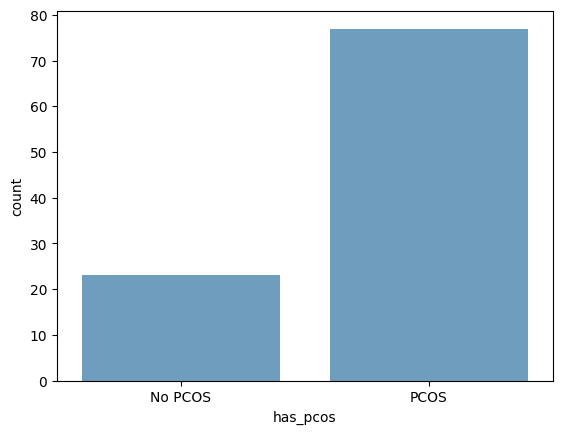

In [21]:
# plot dataset distribution for target variable of 1 and 0
ax = sns.countplot(data=preprocessed_local_dataset, x='has_pcos', alpha=0.7)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No PCOS', 'PCOS'])

In [22]:
# MinMaxScaler
# preprocessed_local_dataset['bmi'] = MinMaxScaler().fit_transform(preprocessed_local_dataset[['bmi']])
# preprocessed_local_dataset['age'] = MinMaxScaler().fit_transform(preprocessed_local_dataset[['age']])

In [23]:
# Define features and target variable
X = preprocessed_local_dataset.drop(columns=['has_pcos'])
y = preprocessed_local_dataset['has_pcos']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)

In [24]:
import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import accuracy_score

In [25]:
def objective(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 3, 25)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    metrics = trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'hamming'])
    p = trial.suggest_int('p', 1, 2)

    knn_pipeline = Pipeline([
        ('scaler', MinMaxScaler()),
        ('knn', KNeighborsClassifier(
            n_neighbors=n_neighbors,
            weights=weights,
            p=p,
            metric=metrics
        ))
    ])

    knn_pipeline.fit(X_train, y_train)
    y_pred_val = knn_pipeline.predict(X_test)
    return accuracy_score(y_test, y_pred_val)

In [26]:

# Apply Tree-structured Parzen Estimator (TPE) Bayesian Optimization
sampler = TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=50)

print("Best Parameters found via Parzen Tree (TPE):", study.best_trial.params)

[I 2026-06-03 21:50:28,262] A new study created in memory with name: no-name-19a089e8-bbdb-4f16-9960-f8a502975ce3
[I 2026-06-03 21:50:28,267] Trial 0 finished with value: 0.8333333333333334 and parameters: {'n_neighbors': 11, 'weights': 'uniform', 'metric': 'euclidean', 'p': 1}. Best is trial 0 with value: 0.8333333333333334.
[I 2026-06-03 21:50:28,270] Trial 1 finished with value: 0.8333333333333334 and parameters: {'n_neighbors': 22, 'weights': 'distance', 'metric': 'manhattan', 'p': 1}. Best is trial 0 with value: 0.8333333333333334.
[I 2026-06-03 21:50:28,272] Trial 2 finished with value: 0.8666666666666667 and parameters: {'n_neighbors': 7, 'weights': 'distance', 'metric': 'euclidean', 'p': 2}. Best is trial 2 with value: 0.8666666666666667.
[I 2026-06-03 21:50:28,275] Trial 3 finished with value: 0.9 and parameters: {'n_neighbors': 6, 'weights': 'distance', 'metric': 'manhattan', 'p': 2}. Best is trial 3 with value: 0.9.
[I 2026-06-03 21:50:28,277] Trial 4 finished with value: 0.

Best Parameters found via Parzen Tree (TPE): {'n_neighbors': 6, 'weights': 'distance', 'metric': 'manhattan', 'p': 2}


In [27]:

# Train model with best parameters
knn_classifier = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(**study.best_trial.params))
])
knn_classifier.fit(X_train, y_train)

y_pred = knn_classifier.predict(X_test)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[ 3  2]
 [ 1 24]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.60      0.67         5
           1       0.92      0.96      0.94        25

    accuracy                           0.90        30
   macro avg       0.84      0.78      0.80        30
weighted avg       0.89      0.90      0.90        30



In [28]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# K-fold validation using best parameters found by TPE (Parzen estimator)
best_knn = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(**study.best_trial.params))
])

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_knn, X, y, cv=kfold, scoring='accuracy')

print("K-Fold Accuracy Scores:", cv_scores)
print(f"Mean K-Fold Accuracy: {cv_scores.mean():.4f}")
print(f"Std K-Fold Accuracy: {cv_scores.std():.4f}")

K-Fold Accuracy Scores: [0.8  0.8  0.7  0.65 0.7 ]
Mean K-Fold Accuracy: 0.7300
Std K-Fold Accuracy: 0.0600


/Users/nickanthonymiras/miniconda3/envs/datascience/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
  0%|          | 0/30 [00:00<?, ?it/s]/Users/nickanthonymiras/miniconda3/envs/datascience/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/nickanthonymiras/miniconda3/envs/datascience/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/nickanthonymiras/miniconda3/envs/datascience/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/nickanthonymiras/miniconda3/envs/datasc

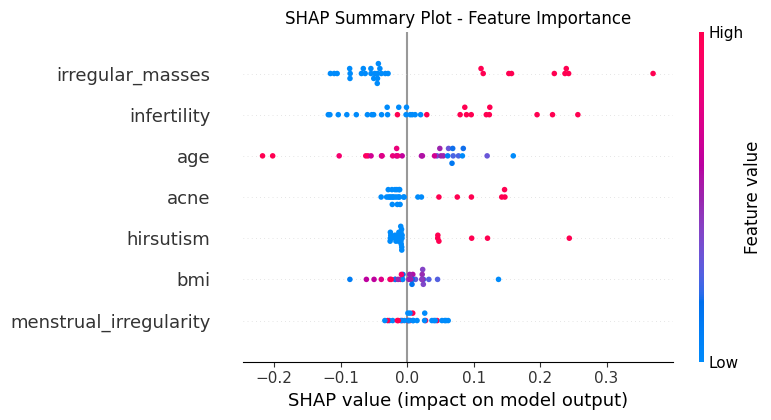

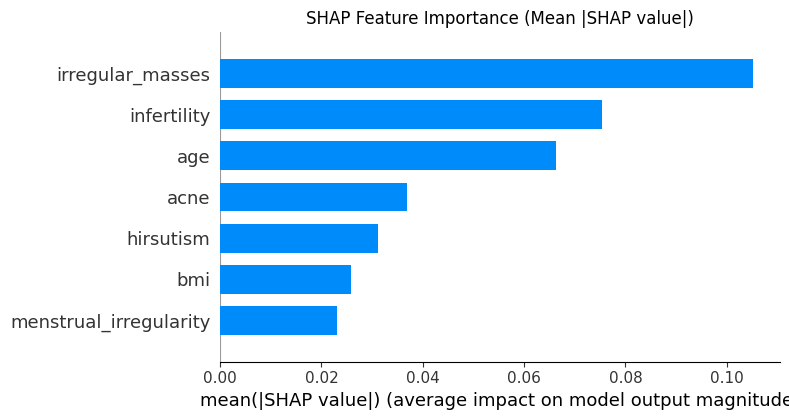


Feature names: ['bmi', 'age', 'infertility', 'menstrual_irregularity', 'acne', 'hirsutism', 'irregular_masses']


In [ ]:
import shap
import matplotlib.pyplot as plt

# Create SHAP explainer for the KNN model
# Using the KNN classifier from the pipeline
knn_model = knn_classifier.named_steps['knn']

# Create explainer with training data
explainer = shap.KernelExplainer(
    lambda x: knn_classifier.predict_proba(x)[:, 1],
    shap.sample(X_train, 100)  # Use a sample of training data for efficiency
)

# Calculate SHAP values for test set
shap_values = explainer.shap_values(X_test)


# Summary plot - shows feature importance
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot - Feature Importance')
plt.tight_layout()
plt.show()

# Bar plot - average impact on model output
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Mean |SHAP value|)')
plt.tight_layout()
plt.show()

print("\nFeature Importance (by mean absolute SHAP value):")
feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False)
print(feature_importance)

# Conclusion